## 07 SpatialCellChat Result Integration

**What this notebook does:** Loads the CellChat outputs from `07_xenium_05_spatialcellchat.R` and integrates them with the niche pseudotime trajectory to show how cell-cell communication changes along PDAC progression.

**Requires:** `07_xenium_05_spatialcellchat.R` to have been run successfully (produces `lr_interaction_summary.csv` and `pathway_summary.csv`).

**Key figures:**
1. L-R interaction strength heatmap across pseudotime bins
2. Top signalling pathway enrichment along progression
3. Ductal-niche-centric communication chord diagram per pseudotime bin
4. Spatial communication hotspot map


In [1]:

from pathlib import Path
import os
_cc_dir = Path("/Users/shihongwu/SpatioEv") / "data" / "xenium_pancreas_10x" / "spatialcellchat"
_required = [_cc_dir / "lr_interaction_summary.csv", _cc_dir / "pathway_summary.csv"]
_missing = [f for f in _required if not f.exists()]
if _missing:
    print(f"Missing CellChat output: {_missing}")
    print("Run 07_xenium_05_spatialcellchat.R in R first.")
else:
    print("CellChat outputs found. Notebook ready to run.")


CellChat outputs found. Notebook ready to run.


## Setup

In [2]:

%matplotlib inline
import os
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import spearmanr

ROOT         = Path("/Users/shihongwu/SpatioEv")
OUTPUT_DIR   = ROOT / "data" / "xenium_pancreas_10x"
CELLCHAT_DIR = OUTPUT_DIR / "spatialcellchat"
FIG_DIR      = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

_pub_rc = {
    "font.family": "sans-serif", "font.sans-serif": ["Arial","Helvetica","DejaVu Sans"],
    "font.size": 7, "axes.titlesize": 8, "axes.labelsize": 7,
    "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 6,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.facecolor": "white", "figure.facecolor": "white",
    "savefig.dpi": 300, "savefig.bbox": "tight",
    "pdf.fonttype": 42, "ps.fonttype": 42,
}
mpl.rcParams.update(_pub_rc)

DISEASE_PALETTE = {"NormalPancreas": "#4CAF50", "PDAC": "#D32F2F"}
PT_BIN_LABELS   = {f"bin{i}": f"PT bin {i}" for i in range(1,6)}
PT_BIN_COLORS   = {f"bin{i}": c for i,c in enumerate(
    ["#4575b4","#91bfdb","#fee090","#fc8d59","#d73027"], start=1
)}

print("Setup complete.")


Setup complete.


## Load CellChat results

In [3]:

# ── Load L-R interaction and pathway tables ───────────────────────────────────
lr_df  = pd.read_csv(CELLCHAT_DIR / "lr_interaction_summary.csv")
pwy_df = pd.read_csv(CELLCHAT_DIR / "pathway_summary.csv")

print(f"L-R interactions: {lr_df.shape}")
print(f"Columns: {list(lr_df.columns)}")
print()
print(f"Pathways: {pwy_df.shape}")
print()

# Normalize column names (CellChat may output slightly different names)
lr_df.columns  = lr_df.columns.str.strip().str.lower().str.replace(" ","_")
pwy_df.columns = pwy_df.columns.str.strip().str.lower().str.replace(" ","_")

display(lr_df.head(5))
display(pwy_df.head(5))


L-R interactions: (8938, 13)
Columns: ['source', 'target', 'ligand', 'receptor', 'prob', 'pval', 'interaction_name', 'interaction_name_2', 'pathway_name', 'annotation', 'evidence', 'sample_id', 'pt_bin']

Pathways: (4543, 7)



,source,target,ligand,receptor,prob,pval,interaction_name,interaction_name_2,pathway_name,annotation,evidence,sample_id,pt_bin
0,B lineage,Endothelial cells,CCL27,CCR2,1.032725e-07,0.0,CCL27_CCR2,CCL27 - CCR2,CCL,Secreted Signaling,KEGG: hsa04060,pdac_pancreas_v1,bin1
1,Endothelial cells,Endothelial cells,CCL27,CCR2,1.251287e-06,0.0,CCL27_CCR2,CCL27 - CCR2,CCL,Secreted Signaling,KEGG: hsa04060,pdac_pancreas_v1,bin1
2,Fibroblasts,Endothelial cells,CCL27,CCR2,7.446937e-07,0.0,CCL27_CCR2,CCL27 - CCR2,CCL,Secreted Signaling,KEGG: hsa04060,pdac_pancreas_v1,bin1
3,Islets,Endothelial cells,CCL27,CCR2,1.506447e-07,0.0,CCL27_CCR2,CCL27 - CCR2,CCL,Secreted Signaling,KEGG: hsa04060,pdac_pancreas_v1,bin1
4,Mast cells,Endothelial cells,CCL27,CCR2,2.185659e-07,0.0,CCL27_CCR2,CCL27 - CCR2,CCL,Secreted Signaling,KEGG: hsa04060,pdac_pancreas_v1,bin1


,source,target,pathway_name,prob,pval,sample_id,pt_bin
0,B lineage,B lineage,CXCL,2.032319e-05,0.0,pdac_pancreas_v1,bin1
1,B lineage,Endothelial cells,CCL,1.032725e-07,0.0,pdac_pancreas_v1,bin1
2,B lineage,Endothelial cells,CXCL,1.677334e-06,0.0,pdac_pancreas_v1,bin1
3,B lineage,Fibroblasts,CCL,1.245510e-07,0.0,pdac_pancreas_v1,bin1
4,B lineage,Fibroblasts,CXCL,2.022936e-06,0.0,pdac_pancreas_v1,bin1


## Stage 1. L-R interaction strength heatmap across pseudotime bins

For each pseudotime bin, show the mean interaction strength of the top ligand-receptor pairs.
Focus on ductal niche as sender OR receiver — the key question is which communication programmes emerge as ductal niches progress from normal to invasive PDAC.


Using probability column: prob


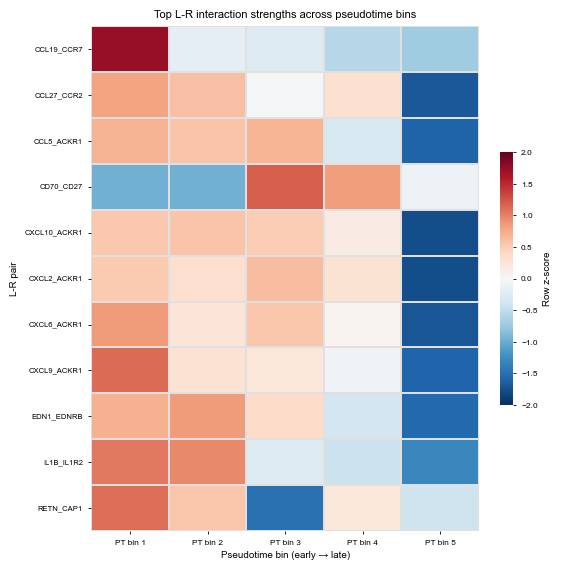

In [4]:

# ── Identify ductal-niche-centric L-R pairs ──────────────────────────────────
DUCTAL_LABEL = "pancreatic ductal epithelium"

# L-R pairs where ductal is sender or receiver
ductal_lr = lr_df[
    (lr_df.get("source", lr_df.get("sender", pd.Series())).astype(str).str.lower().str.contains("ductal", na=False)) |
    (lr_df.get("target", lr_df.get("receiver", pd.Series())).astype(str).str.lower().str.contains("ductal", na=False))
].copy() if "source" in lr_df.columns or "sender" in lr_df.columns else lr_df.copy()

# Find probability / weight column
prob_col = next((c for c in lr_df.columns if c in ["prob","probability","weight","communication_prob"]), None)
if prob_col is None:
    prob_col = [c for c in lr_df.columns if "prob" in c or "weight" in c or "strength" in c]
    prob_col = prob_col[0] if prob_col else lr_df.select_dtypes("number").columns[0]
print(f"Using probability column: {prob_col}")

# L-R pair label
lr_df["lr_pair"] = lr_df.get("interaction_name",
    lr_df.get("ligand","L").astype(str) + "-" + lr_df.get("receptor","R").astype(str))

# Top 20 L-R pairs by overall strength
top_lr = (lr_df.groupby("lr_pair")[prob_col].mean()
           .sort_values(ascending=False).head(20).index.tolist())

# Pivot: lr_pair × pt_bin, mean probability
lr_pivot = (
    lr_df[lr_df["lr_pair"].isin(top_lr)]
    .groupby(["lr_pair","pt_bin"])[prob_col]
    .mean()
    .unstack("pt_bin")
    .fillna(0)
)
# Rename columns
lr_pivot.columns = [PT_BIN_LABELS.get(c, c) for c in lr_pivot.columns]

# Z-score rows
lr_z = (lr_pivot.T - lr_pivot.T.mean()) / lr_pivot.T.std().replace(0,1)
lr_z = lr_z.T.fillna(0)

fig, ax = plt.subplots(figsize=(5.5, 0.4*len(lr_z)+1.2))
sns.heatmap(lr_z, cmap="RdBu_r", center=0, vmin=-2, vmax=2,
            linewidths=0.2, linecolor="#e0e0e0", ax=ax,
            cbar_kws={"shrink":0.5, "label":"Row z-score", "fraction":0.03})
ax.set_xlabel("Pseudotime bin (early → late)", fontsize=7)
ax.set_ylabel("L-R pair", fontsize=7)
ax.set_title("Top L-R interaction strengths across pseudotime bins", fontsize=8, pad=6)
ax.tick_params(axis="y", labelsize=5.5)
plt.tight_layout(pad=0.5)
plt.savefig(FIG_DIR / "fig_cellchat_lr_heatmap.pdf")
plt.show()


## Stage 2. Signalling pathway enrichment along pseudotime

Pathway probability column: prob


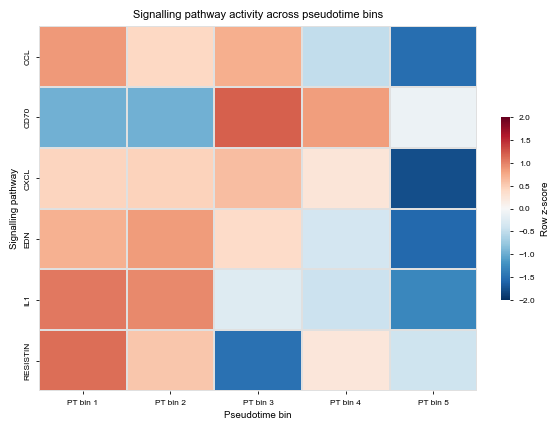

In [5]:

# ── Pathway activity across pseudotime bins ───────────────────────────────────
pwy_prob_col = next((c for c in pwy_df.columns if "prob" in c or "weight" in c), None)
if pwy_prob_col is None:
    pwy_prob_col = pwy_df.select_dtypes("number").columns[0]
print(f"Pathway probability column: {pwy_prob_col}")

pwy_col = next((c for c in pwy_df.columns if "pathway" in c), None)
if pwy_col is None:
    print("Cannot find pathway column — displaying raw table")
    display(pwy_df.head(20))
else:
    top_pwy = (pwy_df.groupby(pwy_col)[pwy_prob_col].mean()
               .sort_values(ascending=False).head(15).index.tolist())

    pwy_pivot = (
        pwy_df[pwy_df[pwy_col].isin(top_pwy)]
        .groupby([pwy_col, "pt_bin"])[pwy_prob_col]
        .mean()
        .unstack("pt_bin")
        .fillna(0)
    )
    pwy_pivot.columns = [PT_BIN_LABELS.get(c, c) for c in pwy_pivot.columns]
    pwy_z = (pwy_pivot.T - pwy_pivot.T.mean()) / pwy_pivot.T.std().replace(0,1)
    pwy_z = pwy_z.T.fillna(0)

    fig, ax = plt.subplots(figsize=(5.5, 0.5*len(pwy_z)+1.2))
    sns.heatmap(pwy_z, cmap="RdBu_r", center=0, vmin=-2, vmax=2,
                linewidths=0.2, linecolor="#e0e0e0", ax=ax,
                cbar_kws={"shrink":0.5, "label":"Row z-score", "fraction":0.03})
    ax.set_xlabel("Pseudotime bin", fontsize=7)
    ax.set_ylabel("Signalling pathway", fontsize=7)
    ax.set_title("Signalling pathway activity across pseudotime bins", fontsize=8, pad=6)
    ax.tick_params(axis="y", labelsize=6)
    plt.tight_layout(pad=0.5)
    plt.savefig(FIG_DIR / "fig_cellchat_pathway_heatmap.pdf")
    plt.show()


## Stage 3. L-R interaction trend lines

For key biologically-motivated signalling axes (TGFβ → desmoplasia, SPP1/CD44 → macrophage-tumour, CXCL/CXCR → neutrophil recruitment), plot mean interaction strength per pseudotime bin as a trend line.


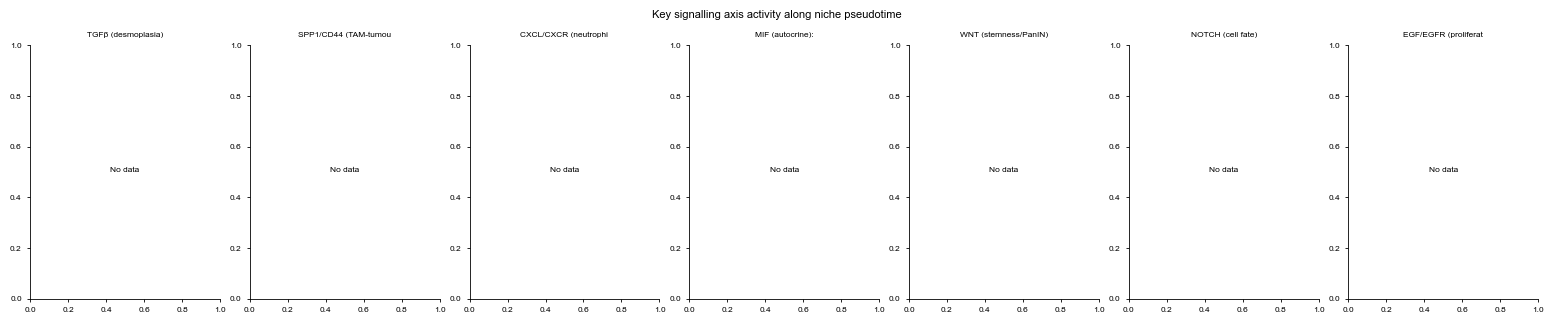

In [6]:

# ── Key signalling axis trends ────────────────────────────────────────────────
SIGNALING_AXES = {
    "TGFβ (desmoplasia)":          ["TGFB1", "TGFB2", "TGFB3"],
    "SPP1/CD44 (TAM-tumour)":      ["SPP1"],
    "CXCL/CXCR (neutrophil)":      ["CXCL5","CXCL8","CXCL1"],
    "MIF (autocrine):":            ["MIF"],
    "WNT (stemness/PanIN)":        ["WNT2","WNT5A","WNT7B"],
    "NOTCH (cell fate)":           ["JAG1","JAG2","DLL1","DLL4"],
    "EGF/EGFR (proliferation)":    ["EGF","AREG","EREG","HBEGF","EPGN"],
}

ligand_col = next((c for c in lr_df.columns if c in ["ligand","l"]), None)
if ligand_col is None:
    print("Cannot find ligand column — showing column names for inspection:")
    print(lr_df.columns.tolist())
else:
    # Bin order for x-axis
    bins_ordered = sorted(lr_df["pt_bin"].unique())
    bin_x = {b: i for i, b in enumerate(bins_ordered)}

    n_axes = len(SIGNALING_AXES)
    fig, axes = plt.subplots(1, n_axes, figsize=(2.2*n_axes, 3.0), sharey=False)
    if n_axes == 1: axes = [axes]

    for ax, (axis_label, ligands) in zip(axes, SIGNALING_AXES.items()):
        sub = lr_df[lr_df[ligand_col].isin(ligands)]
        if len(sub) == 0:
            ax.set_title(axis_label[:20], fontsize=6)
            ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", fontsize=6)
            continue
        trend = sub.groupby("pt_bin")[prob_col].mean().reset_index()
        trend["x"] = trend["pt_bin"].map(bin_x)
        trend = trend.sort_values("x")

        ax.plot(trend["x"], trend[prob_col], color="#D32F2F", lw=1.5, marker="o",
                markersize=4, markerfacecolor="white", markeredgecolor="#D32F2F", markeredgewidth=1)
        ax.fill_between(trend["x"], trend[prob_col], alpha=0.15, color="#D32F2F")
        ax.set_xticks(list(bin_x.values()))
        ax.set_xticklabels([f"PT{i+1}" for i in range(len(bins_ordered))], fontsize=5.5)
        ax.set_title(axis_label, fontsize=6.5, pad=4)
        ax.set_ylabel("Mean L-R interaction prob." if ax == axes[0] else "", fontsize=6)
        for sp in ["top","right"]: ax.spines[sp].set_visible(False)

    fig.suptitle("Key signalling axis activity along niche pseudotime", fontsize=8, y=1.02)
    plt.tight_layout(pad=0.3, w_pad=0.4)
    plt.savefig(FIG_DIR / "fig_cellchat_signaling_trends.pdf")
    plt.show()


## Stage 4. Spatial communication hotspot map

Map the dominant L-R interaction type back to tissue space by colouring each ductal niche according to the highest-weight signalling pathway detected in its pseudotime bin.


Dominant pathway per bin: {'bin3': 'CXCL', 'bin2': 'CXCL', 'bin1': 'CXCL', 'bin4': 'CXCL', 'bin5': 'CXCL'}


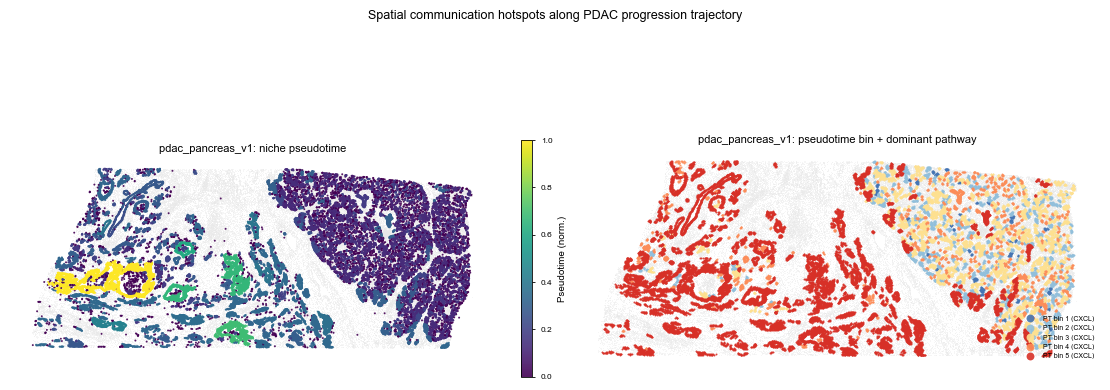

In [7]:

# ── Spatial hotspot map ───────────────────────────────────────────────────────
import scanpy as sc

result_df = pd.read_pickle(OUTPUT_DIR / "pseudotime" / "xenium_pseudotime_result_df.pkl")
niche_bins = pd.read_csv(CELLCHAT_DIR / "niche_pseudotime_bins.csv")

NICHE_KEY = "xenium_ductal_epithelium_component"
SAMPLE_ID  = "pdac_pancreas_v1"   # representative PDAC sample on Multi-Tissue panel

if pwy_col is not None:
    # Dominant pathway per pt_bin
    dominant_pwy = (
        pwy_df.groupby(["pt_bin", pwy_col])[pwy_prob_col]
        .mean()
        .reset_index()
        .sort_values(pwy_prob_col, ascending=False)
        .drop_duplicates("pt_bin")
        .set_index("pt_bin")[pwy_col]
        .to_dict()
    )
    print("Dominant pathway per bin:", dominant_pwy)
else:
    dominant_pwy = {}

# Load annotated h5ad for spatial coordinates
adata_path = OUTPUT_DIR / "annotated_h5ad" / f"{SAMPLE_ID}_annotated.h5ad"
if not adata_path.exists():
    print(f"h5ad not found: {adata_path}")
else:
    # Prefer _with_niches.h5ad (has xenium_ductal_epithelium_component)
    niche_adata_path = OUTPUT_DIR / "niche_features" / f"{SAMPLE_ID}_with_niches.h5ad"
    h5ad_to_load = niche_adata_path if niche_adata_path.exists() else adata_path
    adata = sc.read_h5ad(h5ad_to_load)
    niche_col = NICHE_KEY if NICHE_KEY in adata.obs.columns else None
    keep_cols = ["x_centroid","y_centroid","Tier_A"] + ([niche_col] if niche_col else [])
    obs = adata.obs[[c for c in keep_cols if c in adata.obs.columns]].copy()
    if niche_col is None:
        obs[NICHE_KEY] = None   # no niche assignment — pseudotime merge will give NaN

    # Merge niche pseudotime
    niche_sid = niche_bins[niche_bins["sample_id"]==SAMPLE_ID][
        [NICHE_KEY,"xenium_pseudotime","xenium_pseudotime_norm","pt_bin_cellchat"]
    ]
    obs = obs.merge(niche_sid, on=NICHE_KEY, how="left")

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    # Left: pseudotime spatial map
    ax = axes[0]
    background = obs[obs["Tier_A"].isna() | ~obs["Tier_A"].eq("pancreatic ductal epithelium")]
    ductal     = obs[obs["Tier_A"] == "pancreatic ductal epithelium"]

    ax.scatter(background["x_centroid"], background["y_centroid"],
               c="#e8e8e8", s=0.3, alpha=0.4, linewidths=0, rasterized=True)
    sc_out = ax.scatter(
        ductal["x_centroid"], ductal["y_centroid"],
        c=ductal["xenium_pseudotime_norm"].fillna(-1),
        cmap="viridis", s=2, alpha=0.9, linewidths=0, rasterized=True,
        vmin=0, vmax=1,
    )
    plt.colorbar(sc_out, ax=ax, shrink=0.5, label="Pseudotime (norm.)", fraction=0.03)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.set_title(f"{SAMPLE_ID}: niche pseudotime", fontsize=8)
    ax.axis("off")

    # Right: pseudotime bin (colouring ductal niches by pt_bin → dominant pathway)
    ax = axes[1]
    ax.scatter(background["x_centroid"], background["y_centroid"],
               c="#e8e8e8", s=0.3, alpha=0.4, linewidths=0, rasterized=True)

    bin_cmap = {f"bin{i}": c for i,c in enumerate(
        ["#4575b4","#91bfdb","#fee090","#fc8d59","#d73027"], start=1
    )}
    for bin_id, color in bin_cmap.items():
        subset = ductal[ductal["pt_bin_cellchat"] == bin_id]
        label  = f"{PT_BIN_LABELS.get(bin_id,bin_id)}"
        if dominant_pwy.get(bin_id): label += f" ({dominant_pwy[bin_id]})"
        ax.scatter(subset["x_centroid"], subset["y_centroid"],
                   c=color, s=2, alpha=0.9, linewidths=0, rasterized=True, label=label)

    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.set_title(f"{SAMPLE_ID}: pseudotime bin + dominant pathway", fontsize=8)
    ax.legend(fontsize=5, frameon=False, loc="lower right", markerscale=4)
    ax.axis("off")

    plt.suptitle("Spatial communication hotspots along PDAC progression trajectory", fontsize=9)
    plt.tight_layout(pad=0.5)
    plt.savefig(FIG_DIR / "fig_cellchat_spatial_hotspots.pdf")
    plt.show()


## Notes

- **Figures** saved to `data/xenium_pancreas_10x/figures/`
- The spatial hotspot map uses `pdac_pancreas_v1` as the representative sample (Stage III, Multi-Tissue panel — both normal and PDAC tissue present)
- If CellChat outputs are missing, re-run `07_xenium_05_spatialcellchat.R` in R
- CellChat L-R database and column names may vary with package version; check the column inspection output if any plots are empty
